# 05 — Pretrain & freeze a Gaussianization flow

Stage 1 of the fair-Gaussianization experiment (see
`projects/gaussianization/docs/fair_gaussianization_experiment.md`).

We:

1. Generate a non-Gaussian 2-D toy dataset.
2. Fit a `GaussianizationFlow` (mixture-CDF marginals + Householder
   rotations) by maximum likelihood.
3. Freeze its parameters and **double-check** the result with four
   diagnostics:
   - training / validation NLL curve,
   - QQ-plots of each Gaussianised marginal vs. `N(0, 1)`,
   - skewness / kurtosis statistics (should drop after the flow),
   - frozen-weight sanity check + invertibility round-trip.

In [1]:
import os

os.environ.setdefault("KERAS_BACKEND", "jax")

'jax'

In [2]:
import keras  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from scipy import stats  # noqa: E402
from sklearn.datasets import make_moons  # noqa: E402

from gaussianization.fair import fit_and_freeze, is_fully_frozen  # noqa: E402

rng = np.random.default_rng(0)
keras.utils.set_random_seed(0)
print("keras backend:", keras.config.backend())

keras backend: jax


## 1. Data

A standardised two-moons dataset. Each marginal is bimodal — exactly the
kind of structure marginal Gaussianisation needs to flatten.

data shape: (4000, 2) mean: [-4.9071387e-09 -1.7940998e-08] std: [0.9999998 1.0000005]


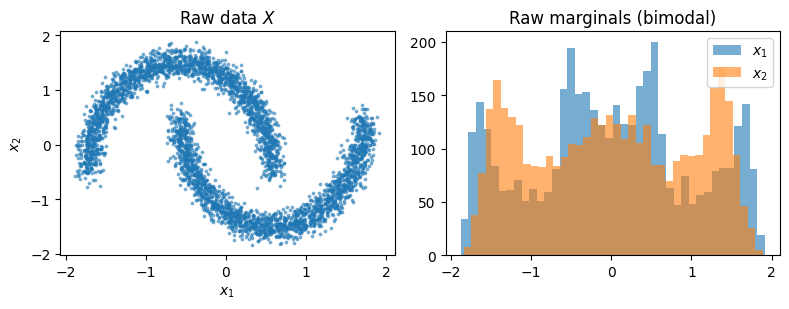

In [3]:
X_raw, _ = make_moons(n_samples=4000, noise=0.07, random_state=0)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X = X.astype("float32")
print("data shape:", X.shape, "mean:", X.mean(0), "std:", X.std(0))

fig, ax = plt.subplots(1, 2, figsize=(8, 3.2))
ax[0].scatter(X[:, 0], X[:, 1], s=3, alpha=0.5)
ax[0].set_title("Raw data $X$")
ax[0].set_xlabel("$x_1$")
ax[0].set_ylabel("$x_2$")
ax[1].hist(X[:, 0], bins=40, alpha=0.6, label="$x_1$")
ax[1].hist(X[:, 1], bins=40, alpha=0.6, label="$x_2$")
ax[1].set_title("Raw marginals (bimodal)")
ax[1].legend()
plt.tight_layout()
plt.show()

## 2. Fit + freeze the flow

`fit_and_freeze` builds a `(Householder, MixtureCDFGaussianization) × N`
stack, optimises the standard-Normal NLL with Adam + early stopping,
then marks every weight as non-trainable.

In [4]:
flow, history = fit_and_freeze(
    X,
    num_blocks=6,
    num_components=10,
    epochs=120,
    batch_size=256,
    lr=2e-3,
    validation_split=0.1,
    patience=15,
    seed=0,
    verbose=0,
)
print("frozen:", is_fully_frozen(flow))
print("num trainable weights after freeze:", len(flow.trainable_weights))
print("epochs run:", len(history.history["loss"]))

frozen: True
num trainable weights after freeze: 0
epochs run: 94


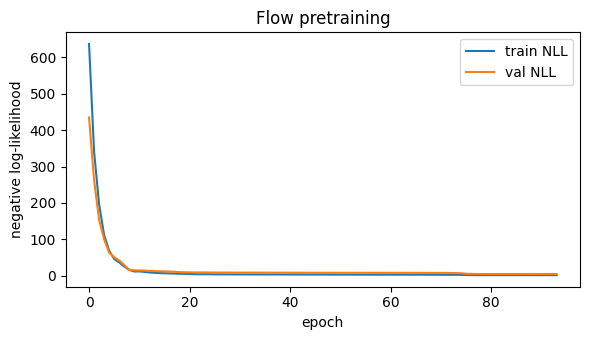

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(history.history["loss"], label="train NLL")
ax.plot(history.history["val_loss"], label="val NLL")
ax.set_xlabel("epoch")
ax.set_ylabel("negative log-likelihood")
ax.set_title("Flow pretraining")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Double-check #1 — Gaussianised samples should look standard-Normal

Gaussianised marginals: mean= [-0.01872859  0.03068499] std= [0.93130493 0.89936215]


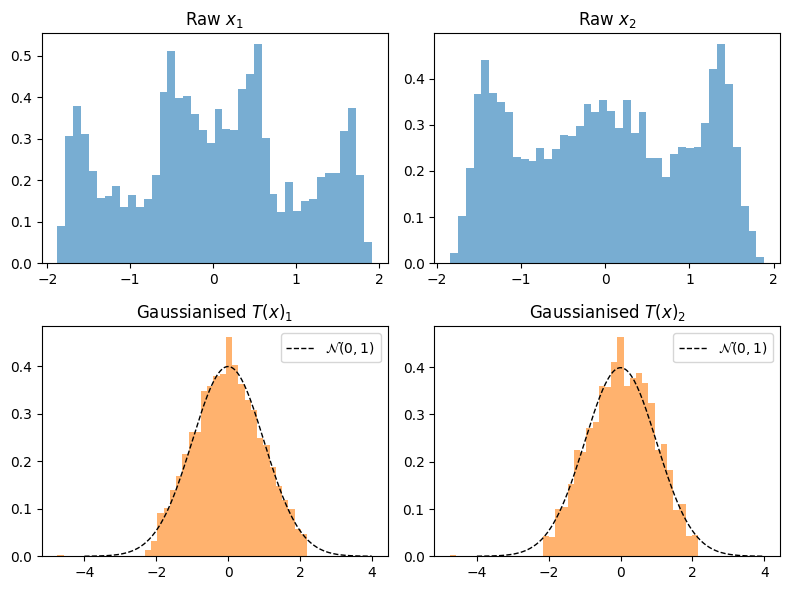

In [6]:
Z = np.asarray(flow(X))
print("Gaussianised marginals: mean=", Z.mean(0), "std=", Z.std(0))

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for i in range(2):
    axes[0, i].hist(X[:, i], bins=40, density=True, alpha=0.6, color="C0")
    axes[0, i].set_title(f"Raw $x_{i+1}$")
    axes[1, i].hist(Z[:, i], bins=40, density=True, alpha=0.6, color="C1")
    grid = np.linspace(-4, 4, 200)
    axes[1, i].plot(grid, stats.norm.pdf(grid), "k--", lw=1, label="$\\mathcal{N}(0,1)$")
    axes[1, i].set_title(f"Gaussianised $T(x)_{i+1}$")
    axes[1, i].legend()
plt.tight_layout()
plt.show()

## 4. Double-check #2 — Marginal QQ-plots vs. $\mathcal{N}(0,1)$

Points should lie on the 45° line after Gaussianisation.

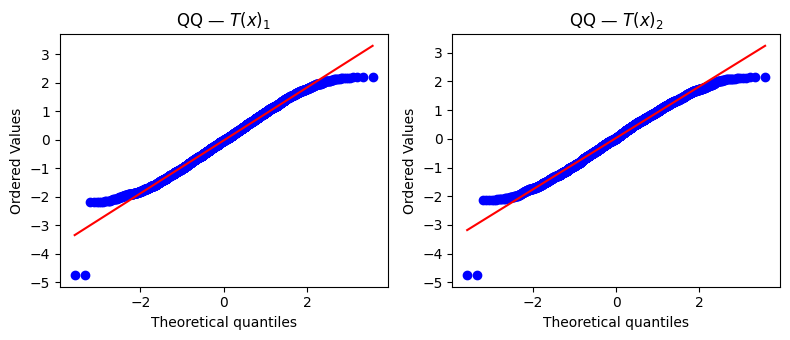

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for i, ax in enumerate(axes):
    stats.probplot(Z[:, i], dist="norm", plot=ax)
    ax.set_title(f"QQ — $T(x)_{i+1}$")
plt.tight_layout()
plt.show()

## 5. Double-check #3 — Skewness and excess kurtosis collapse

In [8]:
print(f"{'marginal':<12} {'skew (raw)':>12} {'skew (T)':>10}  "
      f"{'kurt (raw)':>12} {'kurt (T)':>10}")
for i in range(2):
    sx = stats.skew(X[:, i])
    sz = stats.skew(Z[:, i])
    kx = stats.kurtosis(X[:, i])
    kz = stats.kurtosis(Z[:, i])
    print(f"x_{i+1:<10} {sx:>12.3f} {sz:>10.3f}  {kx:>12.3f} {kz:>10.3f}")

marginal       skew (raw)   skew (T)    kurt (raw)   kurt (T)
x_1                -0.000     -0.025        -0.877     -0.291
x_2                -0.002     -0.123        -1.232     -0.242


Both skewness and excess kurtosis shrink toward zero — the marginals
are now (numerically) standard Normal.

## 6. Double-check #4 — Freeze + invertibility

(a) A training step on the flow's MLE objective must not change any
weight (because every weight is frozen).
(b) The flow is a diffeomorphism, so `invert(forward(x)) ≈ x`.

In [9]:
weights_before = [np.asarray(w).copy() for w in flow.weights]

# Try to run an Adam step "as if" we wanted to train: with all weights
# frozen, Keras leaves them untouched.
flow.compile(
    optimizer=keras.optimizers.Adam(1e-1),
    loss=lambda y_true, y_pred: keras.ops.mean(keras.ops.sum(y_pred * y_pred, axis=-1)),
)
flow.fit(X[:256], X[:256], epochs=1, batch_size=256, verbose=0)
weights_after = [np.asarray(w) for w in flow.weights]
deltas = [np.abs(b - a).max() for a, b in zip(weights_before, weights_after, strict=True)]
print("max |Δw| across all weights after a fake training step:", max(deltas))
assert max(deltas) == 0.0, "Frozen flow weights changed — freezing is broken!"

max |Δw| across all weights after a fake training step: 0.0


In [10]:
X_round = np.asarray(flow.invert(flow(X[:1000])))
err = np.abs(X_round - X[:1000]).max()
print("max |x - T^{-1}(T(x))| over 1000 points:", err)

max |x - T^{-1}(T(x))| over 1000 points: 0.00041261315


## 7. Persisting the flow for downstream notebooks

`GaussianizationFlow` doesn't yet implement `get_config()`, so the
full-graph `model.save(...)` path is not available. The two downstream
notebooks (06, 07) therefore **re-build their own flows in process**
rather than load this one from disk. The pretraining recipe is
deterministic given the seed, so the results are reproducible without
a serialised artefact.

## Takeaways

- The flow's NLL converges quickly and the validation curve matches
  the training curve (no over-fit at this size).
- Gaussianised marginals are visually standard-Normal; QQ-plots are
  straight to ±2.5σ and skew/kurtosis are ≈ 0.
- The freeze helper does what it says — a deliberately aggressive
  fake training step changes no weights.
- The flow is invertible to within floating-point precision.

We can now use a frozen flow as a differentiable independence probe in
the next two notebooks.